In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from __future__ import annotations

import argparse
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

from scipy.stats import pearsonr, spearmanr
import pandas as pd

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

In [2]:
def load_h5(filepath: str | Path, filename: str) -> dict[str, np.ndarray]:
    """
    Load all datasets from an HDF5 file.

    Parameters
    ----------
    filepath
        Directory containing the HDF5 file.

    filename
        Name of the HDF5 file, including the .h5 extension.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary containing all HDF5 datasets.

        The dictionary keys are the full dataset paths inside the
        HDF5 file. The values are NumPy arrays.

    Raises
    ------
    FileNotFoundError
        If the requested HDF5 file does not exist.

    OSError
        If the file exists but cannot be opened as an HDF5 file.
    """
    full_path = Path(filepath) / filename

    if not full_path.is_file():
        raise FileNotFoundError(
            f"HDF5 file was not found: {full_path.resolve()}"
        )

    data: dict[str, np.ndarray] = {}

    with h5py.File(full_path, mode="r") as h5_file:

        def load_dataset(name: str, obj: h5py.Dataset | h5py.Group) -> None:
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[...]

        h5_file.visititems(load_dataset)

    return data

In [3]:
parent_dir = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/BasC/param_space")

# case_names = [
#     "Re010_Ca0_010_theta45",
#     "Re010_Ca0_010_theta45_v2",
#     "Re020_Ca0_010_theta45",
#     "Re050_Ca0_010_theta45",
#     "Re120_Ca0_010_theta45",
# ]

case_names = [
    "Re010_Ca0_010_theta45_v2",
    "Re050_Ca0_010_theta45",
    "Re120_Ca0_010_theta45",
]

filename = "thinfilm_closure_data.h5"

all_closure_data = {}

for case_name in case_names:
    case_dir = parent_dir / case_name
    file_path = case_dir / filename

    if file_path.exists():
        all_closure_data[case_name] = load_h5(case_dir, filename)
        print(f"Loaded: {case_name}")
    else:
        print(f"Missing: {file_path}")

Loaded: Re010_Ca0_010_theta45_v2
Loaded: Re050_Ca0_010_theta45
Loaded: Re120_Ca0_010_theta45


In [4]:
for case_name, closure_data in all_closure_data.items():
    print(f"\n{case_name}")
    print("-" * len(case_name))

    for key, value in closure_data.items():
        print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")


Re010_Ca0_010_theta45_v2
------------------------
  dt                                  shape=(199,), dtype=float64
  h                                   shape=(16384, 199), dtype=float64
  h_m                                 shape=(16384, 199), dtype=float64
  h_x                                 shape=(16384, 199), dtype=float64
  h_xx                                shape=(16384, 199), dtype=float64
  parameters/Ca                       shape=(), dtype=float64
  parameters/Re                       shape=(), dtype=float64
  parameters/angle                    shape=(), dtype=float64
  parameters/h0                       shape=(), dtype=float64
  parameters/mu_ratio                 shape=(), dtype=float64
  parameters/rho_ratio                shape=(), dtype=float64
  parameters/t0                       shape=(), dtype=float64
  parameters/u0                       shape=(), dtype=float64
  q                                   shape=(16384, 199), dtype=float64
  q_m                      

In [5]:
def first_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative with respect to x for a field
    stored as (nx, nt).

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx, nt)
        Field values. The first axis must correspond to x.

        Examples:
            h
            q
            tau_wall
            shape_factor

    Returns
    -------
    dfield_dx : ndarray, shape (nx, nt)
        Fourth-order approximation to df/dx at every time.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1:
        raise ValueError(
            "x must be a one-dimensional array."
        )

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field.shape[0] != x.size:
        raise ValueError(
            "The first dimension of field must equal len(x). "
            f"Received field.shape={field.shape}, "
            f"len(x)={x.size}."
        )

    if x.size < 5:
        raise ValueError(
            "At least five x points are required for "
            "fourth-order differentiation."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid must be uniformly spaced."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # --------------------------------------------------------
    # Interior
    # Fourth-order central difference
    # --------------------------------------------------------

    dfield_dx[2:-2, :] = (
        field[:-4, :]
        - 8.0 * field[1:-3, :]
        + 8.0 * field[3:-1, :]
        - field[4:, :]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Left boundary
    # --------------------------------------------------------

    dfield_dx[0, :] = (
        -25.0 * field[0, :]
        + 48.0 * field[1, :]
        - 36.0 * field[2, :]
        + 16.0 * field[3, :]
        - 3.0 * field[4, :]
    ) / (12.0 * dx)

    dfield_dx[1, :] = (
        -3.0 * field[0, :]
        - 10.0 * field[1, :]
        + 18.0 * field[2, :]
        - 6.0 * field[3, :]
        + field[4, :]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Right boundary
    # --------------------------------------------------------

    dfield_dx[-2, :] = (
        -field[-5, :]
        + 6.0 * field[-4, :]
        - 18.0 * field[-3, :]
        + 10.0 * field[-2, :]
        + 3.0 * field[-1, :]
    ) / (12.0 * dx)

    dfield_dx[-1, :] = (
        3.0 * field[-5, :]
        - 16.0 * field[-4, :]
        + 36.0 * field[-3, :]
        - 48.0 * field[-2, :]
        + 25.0 * field[-1, :]
    ) / (12.0 * dx)

    return dfield_dx

In [6]:
def second_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the second derivative with respect to x for a field
    stored as (nx, nt).

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx, nt)
        Field values. The first axis corresponds to x.

    Returns
    -------
    d2field_dx2 : ndarray, shape (nx, nt)
        Fourth-order approximation to d²f/dx².
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1:
        raise ValueError(
            "x must be one-dimensional."
        )

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field.shape[0] != x.size:
        raise ValueError(
            "The first dimension of field must equal len(x). "
            f"Received field.shape={field.shape}, "
            f"len(x)={x.size}."
        )

    if x.size < 6:
        raise ValueError(
            "At least six x points are required."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid must be uniformly spaced."
        )

    d2field_dx2 = np.empty_like(
        field,
        dtype=float,
    )

    # --------------------------------------------------------
    # Interior
    # --------------------------------------------------------

    d2field_dx2[2:-2, :] = (
        -field[4:, :]
        + 16.0 * field[3:-1, :]
        - 30.0 * field[2:-2, :]
        + 16.0 * field[1:-3, :]
        - field[:-4, :]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Left boundary
    # --------------------------------------------------------

    d2field_dx2[0, :] = (
        45.0 * field[0, :]
        - 154.0 * field[1, :]
        + 214.0 * field[2, :]
        - 156.0 * field[3, :]
        + 61.0 * field[4, :]
        - 10.0 * field[5, :]
    ) / (12.0 * dx**2)

    d2field_dx2[1, :] = (
        10.0 * field[0, :]
        - 15.0 * field[1, :]
        - 4.0 * field[2, :]
        + 14.0 * field[3, :]
        - 6.0 * field[4, :]
        + field[5, :]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Right boundary
    # --------------------------------------------------------

    d2field_dx2[-2, :] = (
        field[-6, :]
        - 6.0 * field[-5, :]
        + 14.0 * field[-4, :]
        - 4.0 * field[-3, :]
        - 15.0 * field[-2, :]
        + 10.0 * field[-1, :]
    ) / (12.0 * dx**2)

    d2field_dx2[-1, :] = (
        -10.0 * field[-6, :]
        + 61.0 * field[-5, :]
        - 156.0 * field[-4, :]
        + 214.0 * field[-3, :]
        - 154.0 * field[-2, :]
        + 45.0 * field[-1, :]
    ) / (12.0 * dx**2)

    return d2field_dx2

In [7]:
def first_derivative_t(
    field: np.ndarray,
    field_minus: np.ndarray,
    time: np.ndarray,
    time_minus: np.ndarray,
) -> np.ndarray:
    """
    Compute first-order backward time derivatives for a field
    stored as (nx, nt).

    Each current snapshot has a corresponding previous snapshot:

        df/dt[:, j] =
            (field[:, j] - field_minus[:, j])
            / (time[j] - time_minus[j])

    Parameters
    ----------
    field : ndarray, shape (nx, nt)
        Quantity at the current snapshot times.

    field_minus : ndarray, shape (nx, nt)
        Same quantity at the corresponding previous times.

    time : ndarray, shape (nt,)
        Current snapshot times.

    time_minus : ndarray, shape (nt,)
        Previous snapshot times.

    Returns
    -------
    dfield_dt : ndarray, shape (nx, nt)
        First-order approximation to df/dt.
    """

    field = np.asarray(field, dtype=float)
    field_minus = np.asarray(field_minus, dtype=float)

    time = np.asarray(time, dtype=float)
    time_minus = np.asarray(time_minus, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if field.ndim != 2:
        raise ValueError(
            "field must have shape (nx, nt)."
        )

    if field_minus.ndim != 2:
        raise ValueError(
            "field_minus must have shape (nx, nt)."
        )

    if field.shape != field_minus.shape:
        raise ValueError(
            "field and field_minus must have identical shapes. "
            f"Received {field.shape} and {field_minus.shape}."
        )

    if time.ndim != 1 or time_minus.ndim != 1:
        raise ValueError(
            "time and time_minus must be one-dimensional."
        )

    if time.shape != time_minus.shape:
        raise ValueError(
            "time and time_minus must have identical shapes."
        )

    if field.shape[1] != time.size:
        raise ValueError(
            "The second dimension of field must match "
            "the number of time values. "
            f"Received field.shape={field.shape}, "
            f"time.size={time.size}."
        )

    dt = time - time_minus

    if np.any(dt <= 0.0):
        bad_indices = np.where(dt <= 0.0)[0]

        raise ValueError(
            "All time values must be greater than their "
            "corresponding time_minus values. "
            f"Bad indices: {bad_indices[:10]}"
        )

    # dt has shape (nt,)
    #
    # field has shape (nx, nt)
    #
    # NumPy broadcasts dt across the x dimension.

    dfield_dt = (
        field - field_minus
    ) / dt[np.newaxis, :]

    return dfield_dt

Interface plots for all cases

In [8]:
for case_name, data in all_closure_data.items():
    t_case = data["t"]

    print(f"{case_name:<30} t_max = {np.max(t_case):10.4f}    snapshots = {len(t_case)}")

Re010_Ca0_010_theta45_v2       t_max =  1990.0000    snapshots = 199
Re050_Ca0_010_theta45          t_max =  1060.0000    snapshots = 106
Re120_Ca0_010_theta45          t_max =   300.0000    snapshots = 30


In [9]:
h_mean = 1.0
h_tolerance = 0.1

analysis_masks = {}

for case_name, data in all_closure_data.items():

    x_case = data["x"]
    h_case = data["h"]
    t_case = data["t"]

    nx, nt = h_case.shape

    analysis_mask = np.zeros((nx, nt), dtype=bool)

    for j in range(nt):

        h_snapshot = h_case[:, j]

        flat = np.abs(h_snapshot - h_mean) <= h_tolerance
        disturbed = ~flat

        disturbed_indices = np.where(disturbed)[0]

        if disturbed_indices.size == 0:
            continue

        last_disturbed_index = disturbed_indices[-1]

        analysis_mask[:last_disturbed_index + 1, j] = True

    analysis_masks[case_name] = analysis_mask

    retained = np.sum(analysis_mask)
    total = analysis_mask.size

    print(f"{case_name:<30} retained = {retained / total * 100:.2f}%")

Re010_Ca0_010_theta45_v2       retained = 93.83%
Re050_Ca0_010_theta45          retained = 84.83%
Re120_Ca0_010_theta45          retained = 39.30%


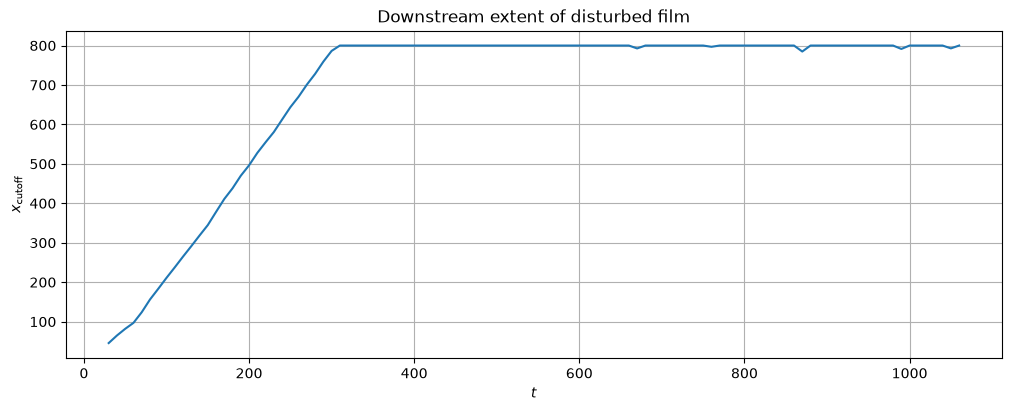

In [10]:
case_name = "Re050_Ca0_010_theta45"

data = all_closure_data[case_name]

x_case = data["x"]
h_case = data["h"]
t_case = data["t"]

mask = analysis_masks[case_name]

x_cutoff = np.full(len(t_case), np.nan)

for j in range(len(t_case)):

    retained_indices = np.where(mask[:, j])[0]

    if retained_indices.size > 0:
        x_cutoff[j] = x_case[retained_indices[-1]]

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

ax.plot(t_case, x_cutoff)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x_{\mathrm{cutoff}}$")
ax.set_title("Downstream extent of disturbed film")
ax.grid(True)

plt.show()

In [11]:
train_fraction = 0.70
val_fraction = 0.15

temporal_splits = {}

for case_name in case_names:

    data = all_closure_data[case_name]

    t = data["t"]
    nt = len(t)

    train_end = int(train_fraction * nt)
    val_end = int((train_fraction + val_fraction) * nt)

    train_indices = np.arange(0, train_end)
    val_indices = np.arange(train_end, val_end)
    test_indices = np.arange(val_end, nt)

    temporal_splits[case_name] = {
        "train": train_indices,
        "val": val_indices,
        "test": test_indices,
    }

    print(f"\n{case_name}")
    print(f"Total snapshots: {nt}")
    print(f"Train: {len(train_indices):3d} snapshots, t = {t[train_indices[0]]:.3f} to {t[train_indices[-1]]:.3f}")
    print(f"Val:   {len(val_indices):3d} snapshots, t = {t[val_indices[0]]:.3f} to {t[val_indices[-1]]:.3f}")
    print(f"Test:  {len(test_indices):3d} snapshots, t = {t[test_indices[0]]:.3f} to {t[test_indices[-1]]:.3f}")


Re010_Ca0_010_theta45_v2
Total snapshots: 199
Train: 139 snapshots, t = 10.000 to 1390.000
Val:    30 snapshots, t = 1400.000 to 1690.000
Test:   30 snapshots, t = 1700.000 to 1990.000

Re050_Ca0_010_theta45
Total snapshots: 106
Train:  74 snapshots, t = 10.000 to 740.000
Val:    16 snapshots, t = 750.000 to 900.000
Test:   16 snapshots, t = 910.000 to 1060.000

Re120_Ca0_010_theta45
Total snapshots: 30
Train:  21 snapshots, t = 10.000 to 210.000
Val:     4 snapshots, t = 220.000 to 250.000
Test:    5 snapshots, t = 260.000 to 300.000


In [12]:
k_space = 4
window_size = 2 * k_space + 1

cnn_data = {}

for case_name in case_names:

    data = all_closure_data[case_name]

    h = data["h"]
    q = data["q"]
    tau_w = data["tau_wall"]

    Re_case = float(data["parameters/Re"])

    nx, nt = h.shape

    tau_w_correction = tau_w - 3.0 * q / h**2

    cnn_data[case_name] = {}

    for split_name in ["train", "val", "test"]:

        time_indices = temporal_splits[case_name][split_name]

        X_list = []
        Y_list = []
        ix_list = []
        it_list = []

        for it in time_indices:

            mask_t = analysis_masks[case_name][:, it]

            for ix in range(k_space, nx - k_space):

                if not mask_t[ix]:
                    continue

                h_window = h[ix - k_space:ix + k_space + 1, it]
                q_window = q[ix - k_space:ix + k_space + 1, it]
                Re_window = np.full(window_size, Re_case)

                X_sample = np.stack([h_window, q_window, Re_window], axis=0)

                X_list.append(X_sample)
                Y_list.append(tau_w_correction[ix, it])
                ix_list.append(ix)
                it_list.append(it)

        X_split = np.asarray(X_list, dtype=np.float32)
        Y_split = np.asarray(Y_list, dtype=np.float32)
        ix_split = np.asarray(ix_list)
        it_split = np.asarray(it_list)

        valid = np.all(np.isfinite(X_split), axis=(1, 2)) & np.isfinite(Y_split)

        X_split = X_split[valid]
        Y_split = Y_split[valid]
        ix_split = ix_split[valid]
        it_split = it_split[valid]

        cnn_data[case_name][split_name] = {
            "X": X_split,
            "Y": Y_split,
            "ix": ix_split,
            "it": it_split,
        }

        print(f"{case_name:<30} {split_name:<5} X = {X_split.shape}   Y = {Y_split.shape}")

Re010_Ca0_010_theta45_v2       train X = (2075925, 3, 9)   Y = (2075925,)
Re010_Ca0_010_theta45_v2       val   X = (490899, 3, 9)   Y = (490899,)
Re010_Ca0_010_theta45_v2       test  X = (490834, 3, 9)   Y = (490834,)
Re050_Ca0_010_theta45          train X = (949209, 3, 9)   Y = (949209,)
Re050_Ca0_010_theta45          val   X = (261648, 3, 9)   Y = (261648,)
Re050_Ca0_010_theta45          test  X = (261699, 3, 9)   Y = (261699,)
Re120_Ca0_010_theta45          train X = (175311, 3, 9)   Y = (175311,)
Re120_Ca0_010_theta45          val   X = (83455, 3, 9)   Y = (83455,)
Re120_Ca0_010_theta45          test  X = (127458, 3, 9)   Y = (127458,)


In [13]:
samples_per_case = 150000
rng = np.random.default_rng(42)

X_scale_list = []
Y_scale_list = []

for case_name in case_names:

    X_case = cnn_data[case_name]["train"]["X"]
    Y_case = cnn_data[case_name]["train"]["Y"]

    n_samples = len(Y_case)

    if n_samples > samples_per_case:
        idx = rng.choice(n_samples, samples_per_case, replace=False)
    else:
        idx = np.arange(n_samples)

    X_scale_list.append(X_case[idx])
    Y_scale_list.append(Y_case[idx])

X_scale = np.concatenate(X_scale_list, axis=0)
Y_scale = np.concatenate(Y_scale_list)

In [14]:
channel_mean = np.mean(X_scale, axis=(0, 2))
channel_std = np.std(X_scale, axis=(0, 2))

Y_mean = np.mean(Y_scale)
Y_std = np.std(Y_scale)

print("Channel means:", channel_mean)
print("Channel stds: ", channel_std)
print("Target mean:  ", Y_mean)
print("Target std:   ", Y_std)

Channel means: [ 0.9634292  1.0067915 60.14651  ]
Channel stds:  [ 0.30179465  0.7513062  45.495132  ]
Target mean:   0.07265014
Target std:    0.8645888


In [15]:
for case_name in case_names:

    for split_name in ["train", "val", "test"]:

        X = cnn_data[case_name][split_name]["X"]
        Y = cnn_data[case_name][split_name]["Y"]

        X_scaled = (X - channel_mean[None, :, None]) / channel_std[None, :, None]
        Y_scaled = (Y - Y_mean) / Y_std

        cnn_data[case_name][split_name]["X_scaled"] = X_scaled.astype(np.float32)
        cnn_data[case_name][split_name]["Y_scaled"] = Y_scaled.astype(np.float32)

In [16]:
samples_per_case = 150000
rng = np.random.default_rng(42)

X_train_list = []
Y_train_list = []

for case_name in case_names:

    X_case = cnn_data[case_name]["train"]["X_scaled"]
    Y_case = cnn_data[case_name]["train"]["Y_scaled"]

    n_samples = len(Y_case)

    if n_samples > samples_per_case:
        idx = rng.choice(n_samples, samples_per_case, replace=False)
    else:
        idx = np.arange(n_samples)

    X_train_list.append(X_case[idx])
    Y_train_list.append(Y_case[idx])

X_train_cnn = np.concatenate(X_train_list, axis=0)
Y_train_cnn = np.concatenate(Y_train_list)

print("X:", X_train_cnn.shape)
print("Y:", Y_train_cnn.shape)

X: (450000, 3, 9)
Y: (450000,)


In [17]:
X_train_tensor = torch.from_numpy(X_train_cnn)
Y_train_tensor = torch.from_numpy(Y_train_cnn).unsqueeze(1)

train_dataset_cnn = TensorDataset(X_train_tensor, Y_train_tensor)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=8192, shuffle=True)

In [18]:
X_val_cnn = np.concatenate([cnn_data[name]["val"]["X_scaled"] for name in case_names], axis=0)
Y_val_cnn = np.concatenate([cnn_data[name]["val"]["Y_scaled"] for name in case_names])

X_val_tensor = torch.from_numpy(X_val_cnn)
Y_val_tensor = torch.from_numpy(Y_val_cnn).unsqueeze(1)

val_dataset_cnn = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=8192, shuffle=False)

In [19]:
class LocalCNN1D(nn.Module):

    def __init__(self, input_channels=3):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.Tanh(),
        )

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):

        x = self.conv(x)

        center = x.shape[-1] // 2

        x = x[:, :, center]

        x = self.head(x)

        return x

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = LocalCNN1D(input_channels=3).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1.0e-3)

print(cnn_model)

LocalCNN1D(
  (conv): Sequential(
    (0): Conv1d(3, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Tanh()
    (2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): Tanh()
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): Tanh()
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [21]:
n_epochs = 100

train_losses_cnn = []
val_losses_cnn = []

best_train_loss = np.inf

model_dir = Path("saved_models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / f"1DCNN_k{k_space}_v01.pt"


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(n_epochs):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    cnn_model.train()

    train_loss_sum = 0.0
    train_count = 0

    for X_batch, Y_batch in train_loader_cnn:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()

        Y_pred = cnn_model(X_batch)

        loss = criterion(Y_pred, Y_batch)

        loss.backward()

        optimizer.step()

        batch_size_current = X_batch.size(0)

        train_loss_sum += loss.item() * batch_size_current
        train_count += batch_size_current

    train_loss = train_loss_sum / train_count


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    cnn_model.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader_cnn:

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            Y_pred = cnn_model(X_batch)

            loss = criterion(Y_pred, Y_batch)

            batch_size_current = X_batch.size(0)

            val_loss_sum += loss.item() * batch_size_current
            val_count += batch_size_current

    val_loss = val_loss_sum / val_count


    # --------------------------------------------------------
    # Store loss history
    # --------------------------------------------------------

    train_losses_cnn.append(train_loss)
    val_losses_cnn.append(val_loss)


    # --------------------------------------------------------
    # Save model if training loss improves
    # --------------------------------------------------------

    if train_loss < best_train_loss:

        best_train_loss = train_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": cnn_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_losses": train_losses_cnn,
            "val_losses": val_losses_cnn,
            "channel_mean": channel_mean,
            "channel_std": channel_std,
            "Y_mean": Y_mean,
            "Y_std": Y_std,
            "k_space": k_space,
            "window_size": window_size,
        }, model_path)

        print(
            f"Epoch {epoch + 1:3d}/{n_epochs}   "
            f"Train = {train_loss:.6e}   "
            f"Val = {val_loss:.6e}   "
            f"Saved"
        )

    else:

        print(
            f"Epoch {epoch + 1:3d}/{n_epochs}   "
            f"Train = {train_loss:.6e}   "
            f"Val = {val_loss:.6e}"
        )


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print()
print(f"Best training loss = {best_train_loss:.6e}")
print(f"Saved model path   = {model_path.resolve()}")

Epoch   1/100   Train = 8.731769e-01   Val = 4.779516e-01   Saved
Epoch   2/100   Train = 4.416318e-01   Val = 3.011468e-01   Saved
Epoch   3/100   Train = 3.289183e-01   Val = 2.052717e-01   Saved
Epoch   4/100   Train = 2.331243e-01   Val = 1.605489e-01   Saved
Epoch   5/100   Train = 1.790111e-01   Val = 1.371614e-01   Saved
Epoch   6/100   Train = 1.503325e-01   Val = 1.211293e-01   Saved
Epoch   7/100   Train = 1.347542e-01   Val = 1.130567e-01   Saved
Epoch   8/100   Train = 1.192834e-01   Val = 1.065610e-01   Saved
Epoch   9/100   Train = 1.120528e-01   Val = 1.117548e-01   Saved
Epoch  10/100   Train = 1.138832e-01   Val = 9.899921e-02
Epoch  11/100   Train = 1.013796e-01   Val = 9.327318e-02   Saved
Epoch  12/100   Train = 9.949600e-02   Val = 9.395651e-02   Saved
Epoch  13/100   Train = 9.696904e-02   Val = 9.445925e-02   Saved
Epoch  14/100   Train = 9.284387e-02   Val = 9.755415e-02   Saved
Epoch  15/100   Train = 9.429036e-02   Val = 8.521159e-02
Epoch  16/100   Train = 8.

In [22]:
X_test_cnn = np.concatenate([cnn_data[name]["test"]["X_scaled"] for name in case_names], axis=0)
Y_test_cnn = np.concatenate([cnn_data[name]["test"]["Y_scaled"] for name in case_names])

X_test_tensor = torch.from_numpy(X_test_cnn.astype(np.float32))
Y_test_tensor = torch.from_numpy(Y_test_cnn.astype(np.float32)).unsqueeze(1)

test_dataset_cnn = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=8192, shuffle=False)

print("CNN test samples:", len(test_dataset_cnn))

CNN test samples: 879991


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

cnn_model.eval()

Y_test_pred_scaled = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader_cnn:

        X_batch = X_batch.to(device)

        Y_pred = cnn_model(X_batch)

        Y_test_pred_scaled.append(Y_pred.cpu().numpy())

Y_test_pred_scaled = np.vstack(Y_test_pred_scaled).ravel()

Y_test_true = Y_test_cnn * Y_std + Y_mean
Y_test_pred = Y_test_pred_scaled * Y_std + Y_mean

mse = mean_squared_error(Y_test_true, Y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test_true, Y_test_pred)
r2 = r2_score(Y_test_true, Y_test_pred)
nrmse = rmse / np.std(Y_test_true)

print(f"MSE   = {mse:.6e}")
print(f"RMSE  = {rmse:.6e}")
print(f"MAE   = {mae:.6e}")
print(f"R2    = {r2:.6f}")
print(f"NRMSE = {nrmse:.6f}")

MSE   = 2.897875e-02
RMSE  = 1.702315e-01
MAE   = 7.398069e-02
R2    = 0.958725
NRMSE = 0.203161


In [24]:
cnn_test_results = {}

for case_name in case_names:

    X_case = cnn_data[case_name]["test"]["X_scaled"].astype(np.float32)
    Y_true = cnn_data[case_name]["test"]["Y"]

    X_tensor = torch.from_numpy(X_case).to(device)

    cnn_model.eval()

    with torch.no_grad():
        Y_pred_scaled = cnn_model(X_tensor).cpu().numpy().ravel()

    Y_pred = Y_pred_scaled * Y_std + Y_mean

    mse = mean_squared_error(Y_true, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_true, Y_pred)
    r2 = r2_score(Y_true, Y_pred)
    nrmse = rmse / np.std(Y_true)

    cnn_test_results[case_name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "NRMSE": nrmse,
    }

    print(case_name)
    print(f"  MSE   = {mse:.6e}")
    print(f"  RMSE  = {rmse:.6e}")
    print(f"  MAE   = {mae:.6e}")
    print(f"  R2    = {r2:.6f}")
    print(f"  NRMSE = {nrmse:.6f}")
    print()

Re010_Ca0_010_theta45_v2
  MSE   = 4.070051e-03
  RMSE  = 6.379695e-02
  MAE   = 3.248720e-02
  R2    = 0.967005
  NRMSE = 0.181645

Re050_Ca0_010_theta45
  MSE   = 2.245251e-02
  RMSE  = 1.498416e-01
  MAE   = 7.815529e-02
  R2    = 0.984659
  NRMSE = 0.123860

Re120_Ca0_010_theta45
  MSE   = 1.383006e-01
  RMSE  = 3.718879e-01
  MAE   = 2.251985e-01
  R2    = 0.898815
  NRMSE = 0.318096



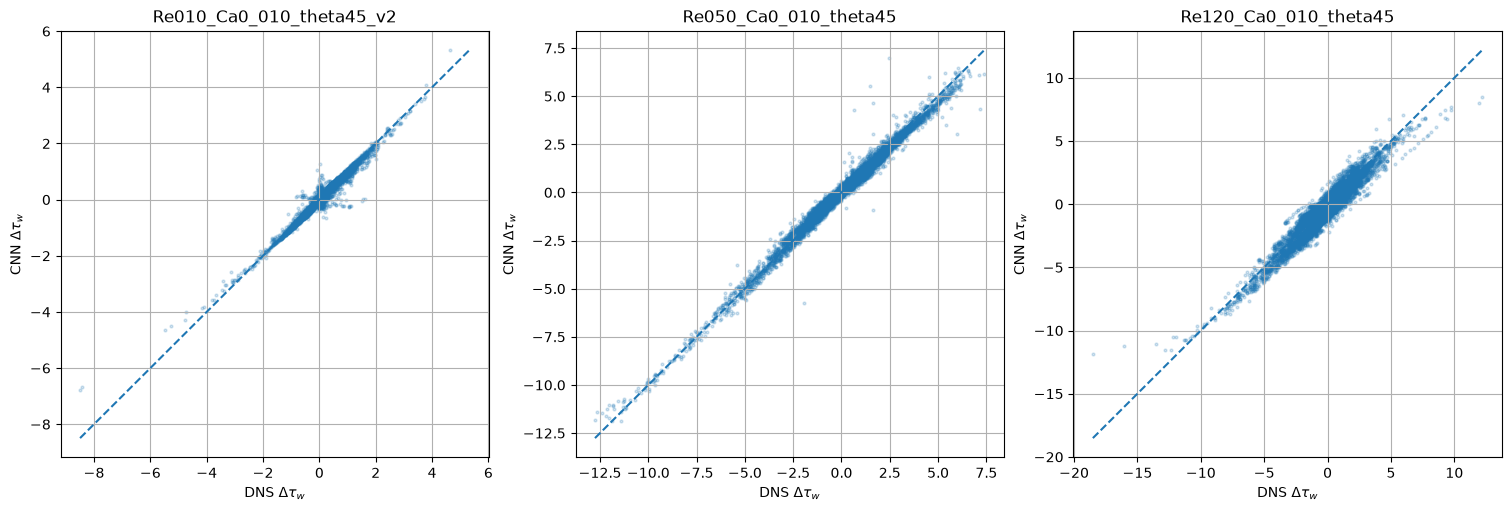

In [25]:
fig, ax = plt.subplots(1, len(case_names), figsize=(15, 5), constrained_layout=True)

sample_size = 30000
rng = np.random.default_rng(42)

for i, case_name in enumerate(case_names):

    X_case = cnn_data[case_name]["test"]["X_scaled"].astype(np.float32)
    Y_true = cnn_data[case_name]["test"]["Y"]

    X_tensor = torch.from_numpy(X_case).to(device)

    cnn_model.eval()

    with torch.no_grad():
        Y_pred_scaled = cnn_model(X_tensor).cpu().numpy().ravel()

    Y_pred = Y_pred_scaled * Y_std + Y_mean

    if len(Y_true) > sample_size:
        idx = rng.choice(len(Y_true), sample_size, replace=False)
    else:
        idx = np.arange(len(Y_true))

    y_min = min(Y_true[idx].min(), Y_pred[idx].min())
    y_max = max(Y_true[idx].max(), Y_pred[idx].max())

    ax[i].scatter(Y_true[idx], Y_pred[idx], s=4, alpha=0.2)
    ax[i].plot([y_min, y_max], [y_min, y_max], "--")

    ax[i].set_title(case_name)
    ax[i].set_xlabel(r"DNS $\Delta\tau_w$")
    ax[i].set_ylabel(r"CNN $\Delta\tau_w$")
    ax[i].grid(True)

plt.show()

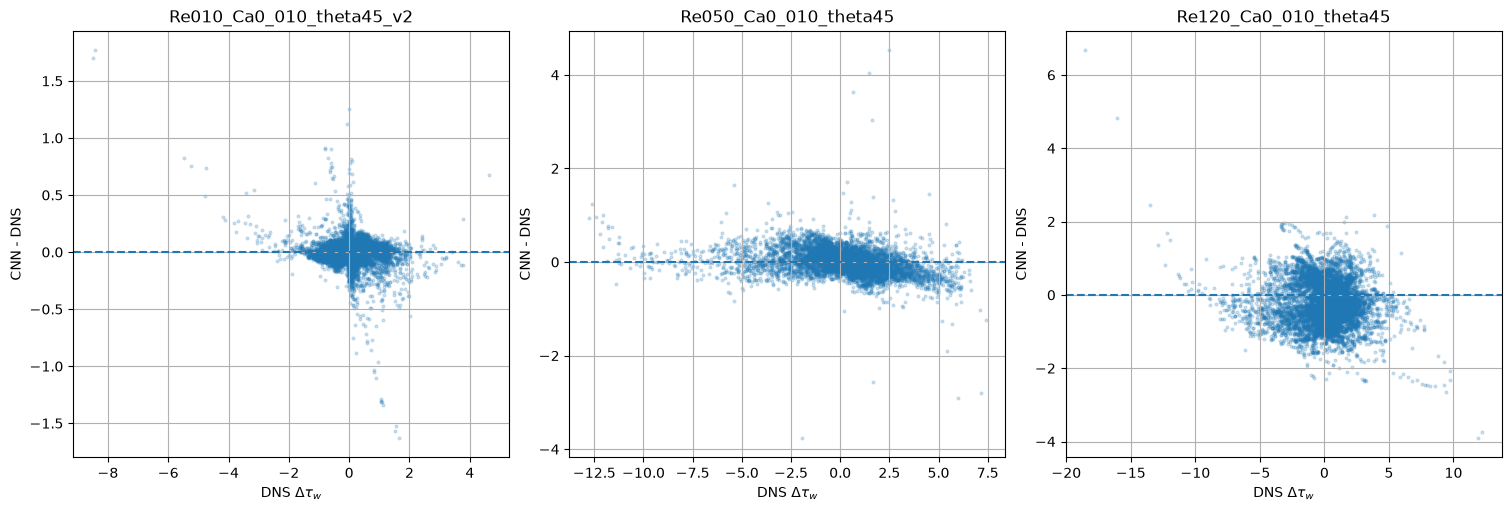

In [26]:
fig, ax = plt.subplots(1, len(case_names), figsize=(15, 5), constrained_layout=True)

sample_size = 30000
rng = np.random.default_rng(42)

for i, case_name in enumerate(case_names):

    X_case = cnn_data[case_name]["test"]["X_scaled"].astype(np.float32)
    Y_true = cnn_data[case_name]["test"]["Y"]

    X_tensor = torch.from_numpy(X_case).to(device)

    cnn_model.eval()

    with torch.no_grad():
        Y_pred_scaled = cnn_model(X_tensor).cpu().numpy().ravel()

    Y_pred = Y_pred_scaled * Y_std + Y_mean

    residual = Y_pred - Y_true

    if len(Y_true) > sample_size:
        idx = rng.choice(len(Y_true), sample_size, replace=False)
    else:
        idx = np.arange(len(Y_true))

    ax[i].scatter(Y_true[idx], residual[idx], s=4, alpha=0.2)
    ax[i].axhline(0.0, linestyle="--")

    ax[i].set_title(case_name)
    ax[i].set_xlabel(r"DNS $\Delta\tau_w$")
    ax[i].set_ylabel("CNN - DNS")
    ax[i].grid(True)

plt.show()